<a href="https://colab.research.google.com/github/Shreya-Kumari274/sale-data-analysis/blob/master/sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# load dataset
df = pd.read_csv("amazon.csv.zip")

print("first 5 rows:")
print(df.head)

print ("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
print(df.info())


first 5 rows:
<bound method NDFrame.head of       product_id                                       product_name  \
0     B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1     B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2     B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3     B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4     B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
...          ...                                                ...   
1460  B08L7J3T31  Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...   
1461  B01M6453MB  Prestige Delight PRWO Electric Rice Cooker (1 ...   
1462  B009P2LIL4  Bajaj Majesty RX10 2000 Watts Heat Convector R...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1464  B01486F4G6  Borosil Jumbo 1000-Watt Grill Sandwich Maker (...   

                                               category discounted_price  \
0     Computers&Accessories

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [ ]:
# Remove duplicate records
df = df.drop_duplicates()

# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Remove rows where important fields are missing
df = df.dropna(subset=["product_id", "product_name", "category"])

# Clean price columns
df["discounted_price"] = (
    df["discounted_price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["actual_price"] = (
    df["actual_price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

# Convert price columns to numeric
df["discounted_price"] = pd.to_numeric(
    df["discounted_price"], errors="coerce"
)

df["actual_price"] = pd.to_numeric(
    df["actual_price"], errors="coerce"
)

# Clean discount percentage
df["discount_percentage"] = (
    df["discount_percentage"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

df["discount_percentage"] = pd.to_numeric(
    df["discount_percentage"], errors="coerce"
)

# Clean rating column
df["rating"] = pd.to_numeric(
    df["rating"], errors="coerce"
)

# Clean rating_count column
df["rating_count"] = (
    df["rating_count"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["rating_count"] = pd.to_numeric(
    df["rating_count"], errors="coerce"
)

# Remove rows with invalid important numerical values
df = df.dropna(
    subset=[
        "discounted_price",
        "actual_price",
        "rating",
        "rating_count"
    ]
)

# Remove invalid values
df = df[df["discounted_price"] >= 0]
df = df[df["actual_price"] >= 0]
df = df[df["discount_percentage"].between(0, 100)]
df = df[df["rating"].between(0, 5)]
df = df[df["rating_count"] >= 0]

# Check cleaned dataset
print("Cleaned dataset shape:", df.shape)

# Display first 5 rows
print(df.head())

Missing values:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64
Cleaned dataset shape: (1462, 16)
   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category  discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...  

### Missing Value Handling

As observed from the `df.isnull().sum()` output before dropping rows, only `rating_count` had 2 missing values. The subsequent cleaning steps, specifically `df.dropna(subset=...)`, effectively removed these rows, ensuring that all critical columns now have no missing values. The printed `Cleaned dataset shape:` confirms the reduction in rows after these operations.

In [ ]:
# Create useful data columns - This section is currently commented out
# as there is no 'Order Date' or similar date column in the dataset
# to extract year, month, etc. from. 'product_id' is an identifier, not a date.

# df["year"]=df["product_id"].dt.year
# df["month"]=df["product_id"].dt.month
# df["month Name"]=df["product_id"].dt.strftime("%b")
# df["year-month"]=df["product_id"].dt.to_period("M").astype(str)

In [ ]:
# EXPLORATORY DATA ANALYSIS

# BASIC STATISTICS
print(df.describe())

       discounted_price   actual_price  discount_percentage       rating  \
count       1462.000000    1462.000000          1462.000000  1462.000000   
mean        3129.981826    5453.087743            47.672367     4.096717   
std         6950.548042   10884.467444            21.613905     0.289497   
min           39.000000      39.000000             0.000000     2.000000   
25%          325.000000     800.000000            32.000000     4.000000   
50%          799.000000    1670.000000            50.000000     4.100000   
75%         1999.000000    4321.250000            63.000000     4.300000   
max        77990.000000  139900.000000            94.000000     5.000000   

        rating_count  
count    1462.000000  
mean    18307.376881  
std     42766.096572  
min         2.000000  
25%      1191.500000  
50%      5179.000000  
75%     17342.250000  
max    426973.000000  


In [ ]:
# Convert discount_percentage to a proportion (if not already done)
# The '.str.replace' part is no longer needed as the column is already numeric.
# Check if the column values are greater than 1, indicating they are still in percentage format (e.g., 64 instead of 0.64).
if df['discount_percentage'].max() > 1:
    df['discount_percentage'] = df['discount_percentage'] / 100

#print("Discount Percentage (as proportion):")
#print(df['discount_percentage'].head())

In [ ]:
#f['discount_percentage'] = df['discount_percentage'].str.replace('%','').astype('float64')

df['discount_percentage'] = df['discount_percentage'] / 100

In [ ]:
#  TOTAL RATING OF PRODUCT

df['rating'].value_counts()

,count
rating,
4.1,244
4.3,230
4.2,228
4.0,181
3.9,123
4.4,123
3.8,86
4.5,75
3.7,42


In [ ]:
print(df['rating'].unique())
df.query('rating == "|"')

[4.2 4.  3.9 4.1 4.3 4.4 4.5 3.7 3.3 3.6 3.4 3.8 3.5 4.6 3.2 5.  4.7 3.
 2.8 3.1 4.8 2.3 2.  2.6 2.9]


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link


In [ ]:
# TOTAL DISCOUNT OF PTODUCT

total_discount_percentage =df ["discount_percentage"].sum()
print ("total discount:", total_discount_percentage)

total discount: 6.9697


In [ ]:
total_products = df["product_id"].nunique()
print("Total unique products:", total_products)

Total unique products: 1348


In [ ]:
correlation = df['discount_percentage'].corr(df['rating'])
print(f"Correlation between Discount Percentage and Rating: {correlation}")

Correlation between Discount Percentage and Rating: -0.15567900856041988


In [ ]:
df['rating'] = df['rating'].replace('|',3.9)

In [ ]:
df['rating_count'] = df['rating_count'].astype(str).str.replace(',', '').astype('float64')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1462 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1462 non-null   object 
 1   product_name         1462 non-null   object 
 2   category             1462 non-null   object 
 3   discounted_price     1462 non-null   float64
 4   actual_price         1462 non-null   float64
 5   discount_percentage  1462 non-null   float64
 6   rating               1462 non-null   float64
 7   rating_count         1462 non-null   float64
 8   about_product        1462 non-null   object 
 9   user_id              1462 non-null   object 
 10  user_name            1462 non-null   object 
 11  review_id            1462 non-null   object 
 12  review_title         1462 non-null   object 
 13  review_content       1462 non-null   object 
 14  img_link             1462 non-null   object 
 15  product_link         1462 non-null   object

In [ ]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000
mean,3129.981826,5453.087743,0.004767,4.096717,18307.376881
std,6950.548042,10884.467444,0.002161,0.289497,42766.096572
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,0.003200,4.000000,1191.500000
50%,799.000000,1670.000000,0.005000,4.100000,5179.000000
75%,1999.000000,4321.250000,0.006300,4.300000,17342.250000
max,77990.000000,139900.000000,0.009400,5.000000,426973.000000


        
        MISSING VALUES

In [ ]:
df.isnull().sum().sort_values(ascending = False)


,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,0
about_product,0
user_id,0


In [ ]:
round(df.isnull().sum() / len(df) * 100, 2).sort_values(ascending=False)

,0
product_id,0.0
product_name,0.0
category,0.0
discounted_price,0.0
actual_price,0.0
discount_percentage,0.0
rating,0.0
rating_count,0.0
about_product,0.0
user_id,0.0


In [ ]:
print(round(df.isnull().sum() / len(df) * 100, 2).sort_values(ascending=False))

product_id             0.0
product_name           0.0
category               0.0
discounted_price       0.0
actual_price           0.0
discount_percentage    0.0
rating                 0.0
rating_count           0.0
about_product          0.0
user_id                0.0
user_name              0.0
review_id              0.0
review_title           0.0
review_content         0.0
img_link               0.0
product_link           0.0
dtype: float64


In [ ]:
# Find total number of missing values
df.isnull().sum().sum()

np.int64(0)

<Axes: >

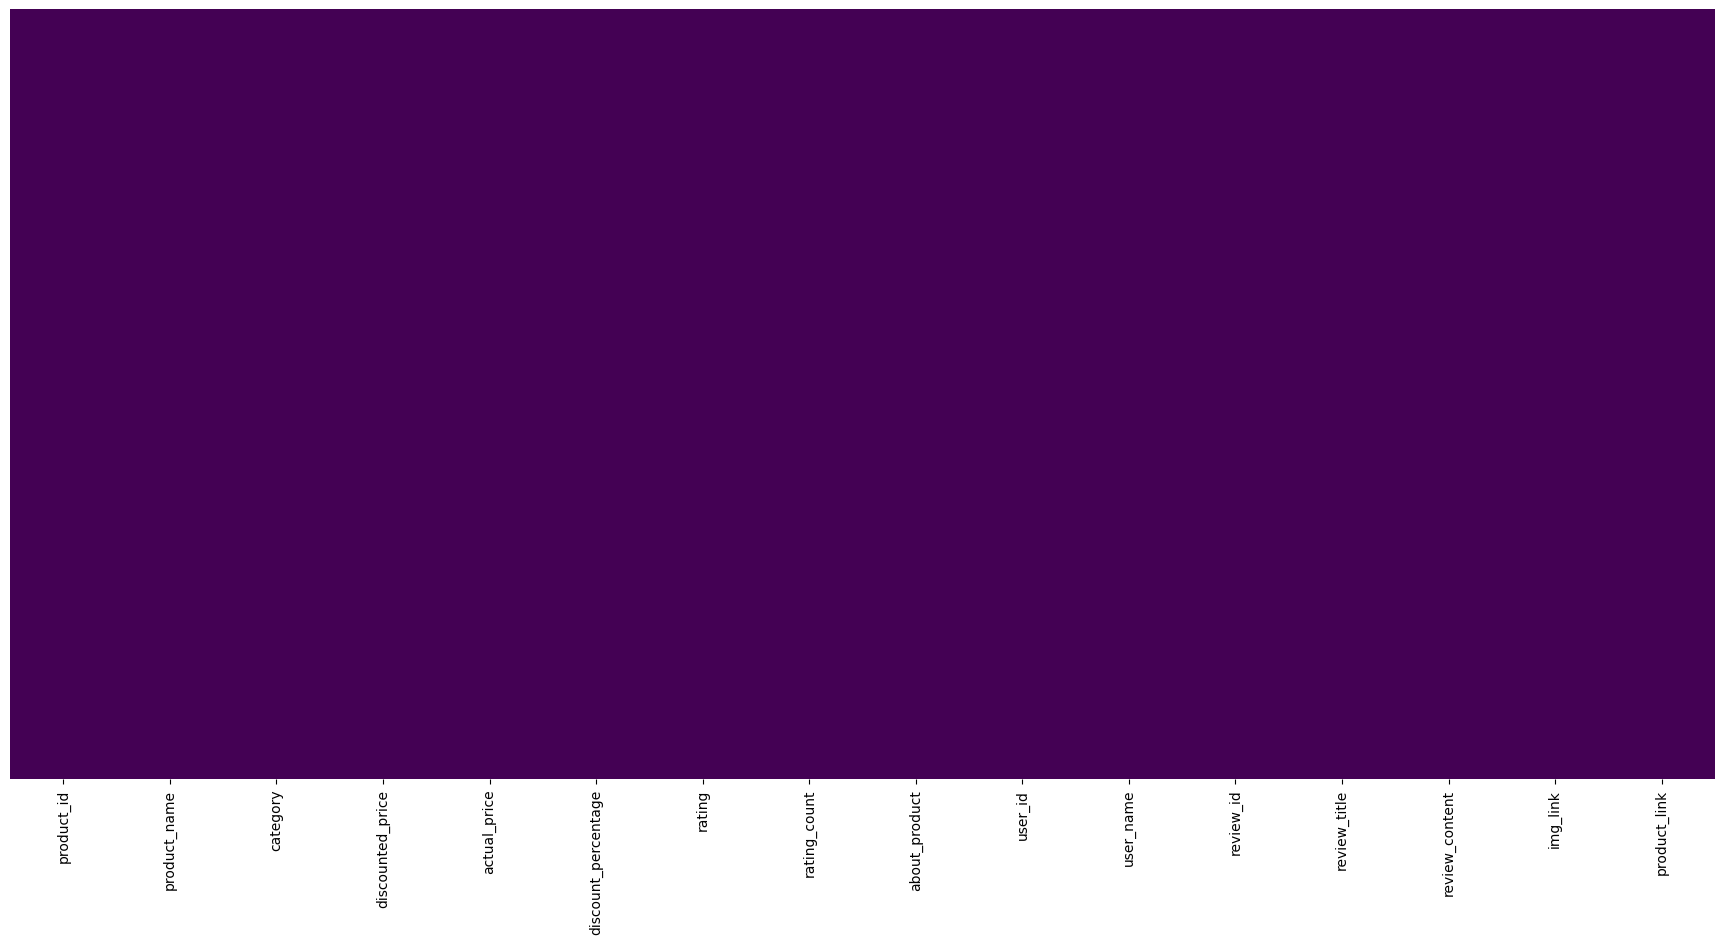

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22, 10))
# plot the null values in each column
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

product_id             0.0
product_name           0.0
category               0.0
discounted_price       0.0
actual_price           0.0
discount_percentage    0.0
rating                 0.0
rating_count           0.0
about_product          0.0
user_id                0.0
user_name              0.0
review_id              0.0
review_title           0.0
review_content         0.0
img_link               0.0
product_link           0.0
dtype: float64


Text(0.5, 1.0, 'Percentage of Missing Values in each Column')

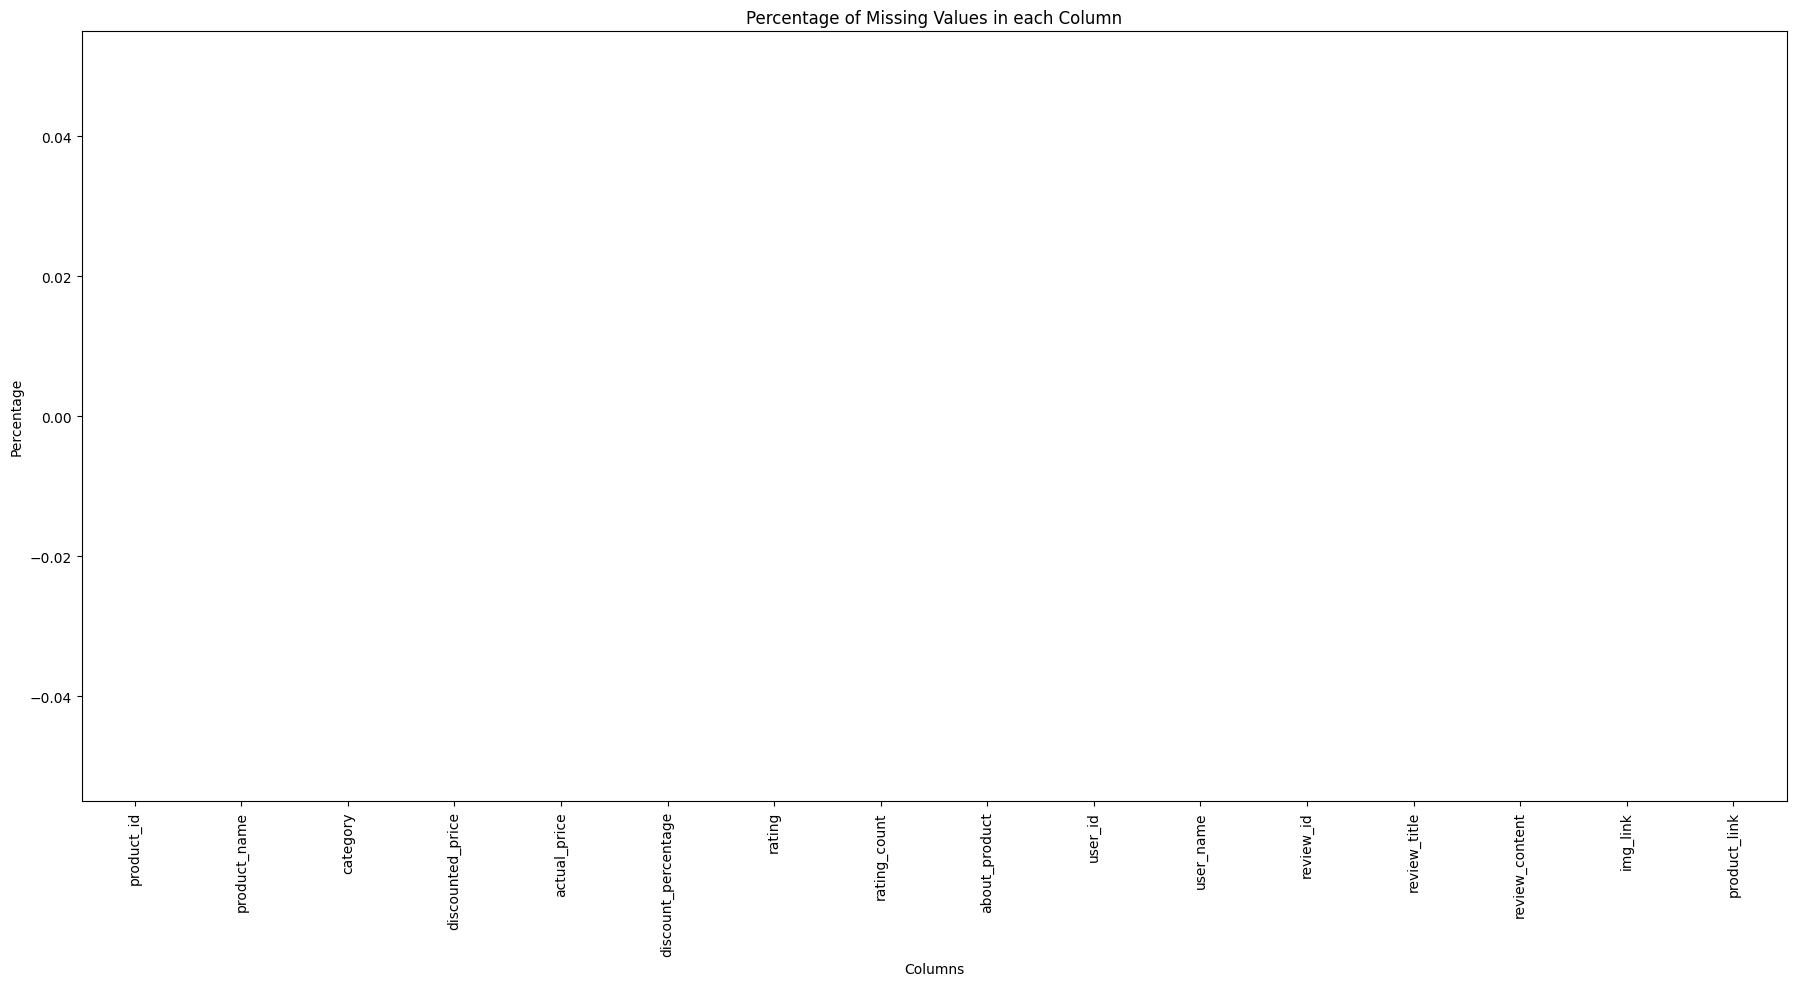

In [ ]:
# make figure size
plt.figure(figsize=(22, 10))
# plot the null values by their percentage in each column
missing_percentage = df.isnull().sum()/len(df)*100
missing_percentage.plot(kind='bar')
print(missing_percentage)
# add the labels
plt.xlabel('Columns')
plt.ylabel('Percentage')
plt.title('Percentage of Missing Values in each Column')

  #  DATA VISUALIZATION

---





#           SCATTER PLOT


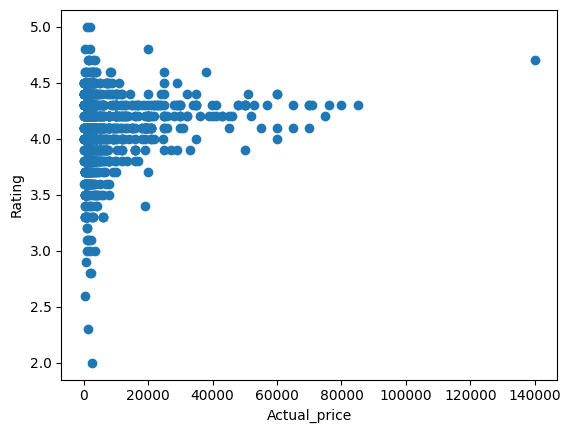

In [ ]:
# Plot actual_price vs. rating
plt.scatter(df['actual_price'], df['rating'])
plt.xlabel('Actual_price')
plt.ylabel('Rating')
plt.show()

In [ ]:
# dont show warnings
import warnings
warnings.filterwarnings('ignore')

 #     HISTOGRAM

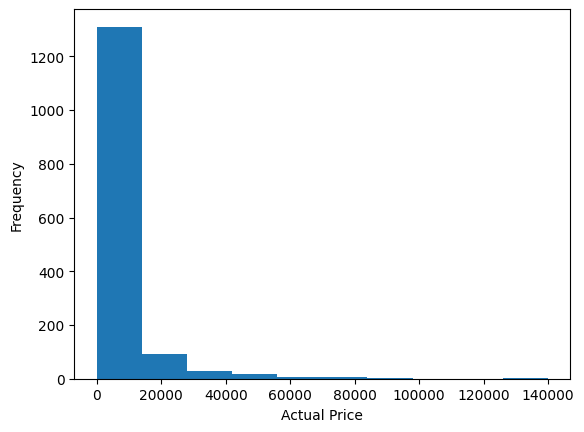

In [ ]:
# Plot distribution of actual_price
plt.hist(df['actual_price'])
plt.xlabel('Actual Price')
plt.ylabel('Frequency')
plt.show()

#     HEATMAP

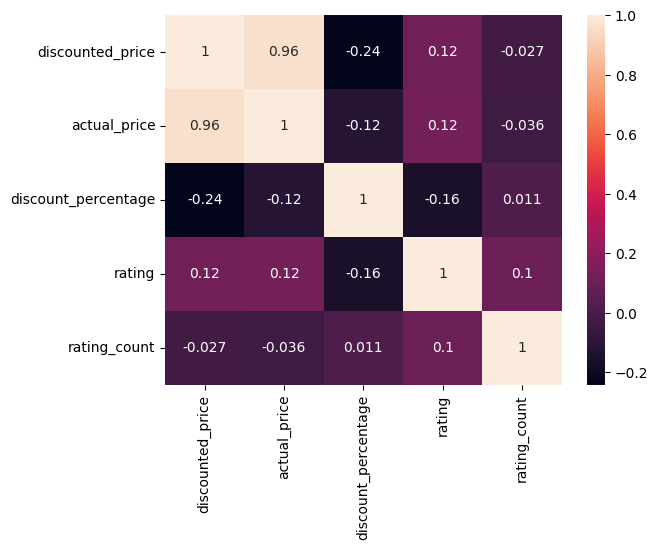

In [ ]:
# Plot correlations between variables
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True)
plt.show()

                     discounted_price  actual_price  discount_percentage  \
discounted_price             1.000000      0.961910            -0.242298   
actual_price                 0.961910      1.000000            -0.117855   
discount_percentage         -0.242298     -0.117855             1.000000   
rating                       0.121132      0.122467            -0.155679   
rating_count                -0.027304     -0.036215             0.011294   

                       rating  rating_count  
discounted_price     0.121132     -0.027304  
actual_price         0.122467     -0.036215  
discount_percentage -0.155679      0.011294  
rating               1.000000      0.102235  
rating_count         0.102235      1.000000  


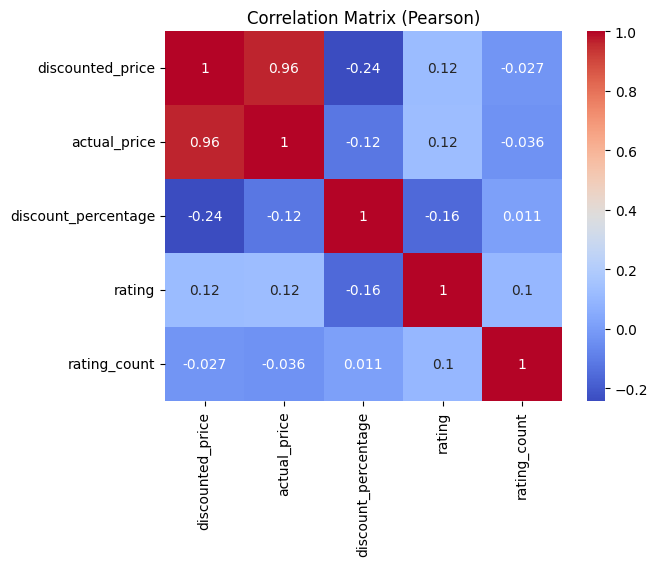

                     discounted_price  actual_price  discount_percentage  \
discounted_price             1.000000      0.933083            -0.371085   
actual_price                 0.933083      1.000000            -0.065069   
discount_percentage         -0.371085     -0.065069             1.000000   
rating                       0.080080      0.033554            -0.146194   
rating_count                 0.123127      0.093793            -0.097713   

                       rating  rating_count  
discounted_price     0.080080      0.123127  
actual_price         0.033554      0.093793  
discount_percentage -0.146194     -0.097713  
rating               1.000000      0.180632  
rating_count         0.180632      1.000000  


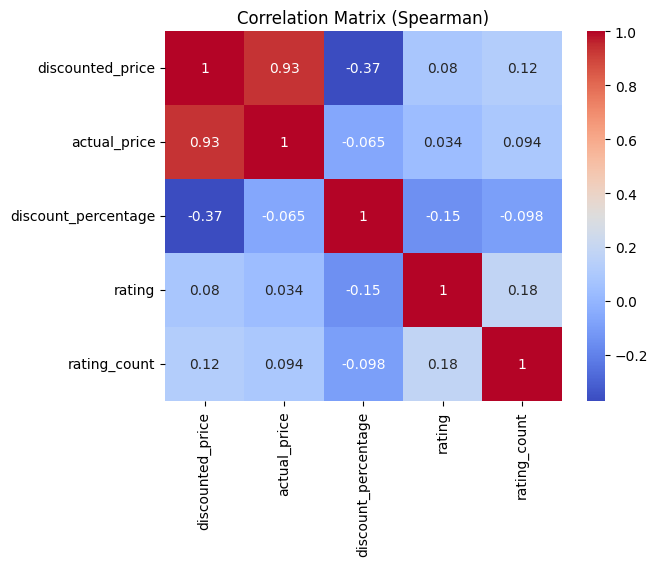

In [ ]:
# Calculate Pearson correlation coefficients (default in Pandas)
correlation_matrix = df.corr(numeric_only=True)

# Print the correlation matrix
print(correlation_matrix)

# Create a heatmap to visualize the correlations
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Pearson)")
plt.show()

# Calculate Spearman correlation coefficients (for non-linear relationships)
spearman_correlation_matrix = df.corr(method="spearman", numeric_only=True)

# Print the Spearman correlation matrix
print(spearman_correlation_matrix)

# Create a heatmap to visualize the Spearman correlations
sns.heatmap(spearman_correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Spearman)")
plt.show()

#Business Insight


--- Top 5 Most Discounted Products ---
                                          product_name  discount_percentage  \
695  rts [2 Pack] Mini USB C Type C Adapter Plug, T...               0.0094   
372  Fire-Boltt Ninja Call Pro Plus 1.83" Smart Wat...               0.0091   
364  Fire-Boltt Ninja Call Pro Plus 1.83" Smart Wat...               0.0091   
380  Fire-Boltt Ninja Call Pro Plus 1.83" Smart Wat...               0.0091   
334  Fire-Boltt Ninja Call Pro Plus 1.83" Smart Wat...               0.0091   

     actual_price  discounted_price  
695        4999.0             294.0  
372       19999.0            1799.0  
364       19999.0            1799.0  
380       19999.0            1799.0  
334       19999.0            1799.0  

--- Top 5 Highest Rated Products (with >1000 reviews) ---
                                           product_name  rating  rating_count  \
1145  Swiffer Instant Electric Water Heater Faucet T...     4.8       53803.0   
1299  Instant Pot Air Fryer, Vortex 

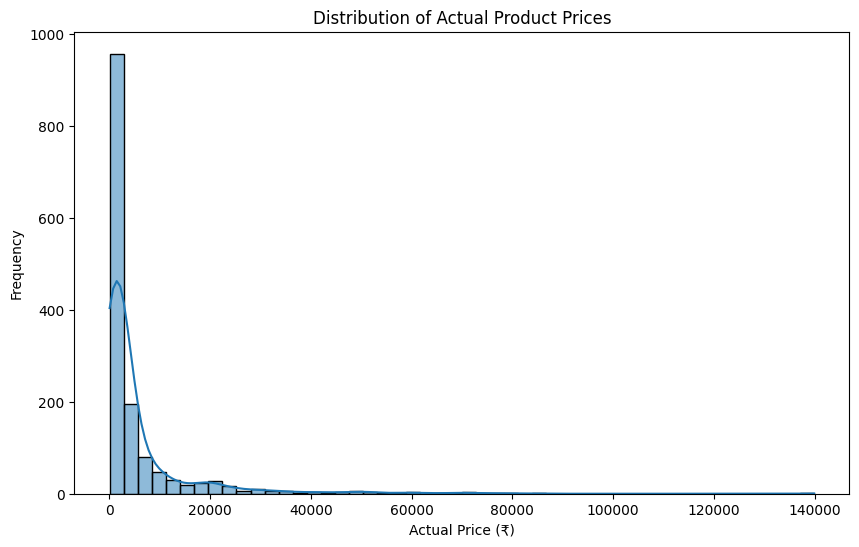


--- Most Expensive Product ---
Product Name: Sony Bravia 164 cm (65 inches) 4K Ultra HD Smart LED Google TV KD-65X74K (Black)
Actual Price: ₹139900.0

--- Cheapest Product ---
Product Name: E-COSMOS 5V 1.2W Portable Flexible USB LED Light (Colours May Vary, Small, EC-POF1)
Actual Price: ₹39.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Insight 1: Top 5 Most Discounted Products
print("\n--- Top 5 Most Discounted Products ---")
top_discounted_products = df.sort_values(by='discount_percentage', ascending=False).head(5)
print(top_discounted_products[['product_name', 'discount_percentage', 'actual_price', 'discounted_price']])

# Insight 2: Top 5 Highest Rated Products (with significant rating count)
# Filtering for products with at least 1000 ratings to ensure significance
print("\n--- Top 5 Highest Rated Products (with >1000 reviews) ---")
high_rated_products = df[df['rating_count'] >= 1000].sort_values(by=['rating', 'rating_count'], ascending=[False, False]).head(5)
print(high_rated_products[['product_name', 'rating', 'rating_count', 'actual_price']])

# Insight 3: Average Rating per Category
print("\n--- Average Rating per Category (Top 10) ---")
cat_avg_rating = df.groupby('category')['rating'].mean().sort_values(ascending=False).head(10)
print(cat_avg_rating)

# Insight 4: Average Discount per Category
print("\n--- Average Discount Percentage per Category (Top 10) ---")
cat_avg_discount = df.groupby('category')['discount_percentage'].mean().sort_values(ascending=False).head(10)
print(cat_avg_discount)

# Insight 5: Price Distribution
print("\n--- Distribution of Actual Prices ---")
plt.figure(figsize=(10, 6))
sns.histplot(df['actual_price'], bins=50, kde=True)
plt.title('Distribution of Actual Product Prices')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Frequency')
plt.show()

# Most Expensive and Cheapest Products
print("\n--- Most Expensive Product ---")
most_expensive = df.loc[df['actual_price'].idxmax()]
print(f"Product Name: {most_expensive['product_name']}")
print(f"Actual Price: ₹{most_expensive['actual_price']}")

print("\n--- Cheapest Product ---")
cheapest = df.loc[df['actual_price'].idxmin()]
print(f"Product Name: {cheapest['product_name']}")
print(f"Actual Price: ₹{cheapest['actual_price']}")